In [1]:
# Ensures Jupyter reloads modules whenever .py files are modified
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

current_directory = Path.cwd()
print("Current Working Directory:", current_directory)

Current Working Directory: C:\Users\ch\Py_PC\Forecasting\LinearBenchTreeSuite\notebooks\analysis


In [3]:
import sys

# Your project path should now appear automatically
print("\n".join(sys.path))

# You can now import your code directly
import dataprocessing


C:\Users\ch\Py_PC\Forecasting\LinearBenchTreeSuite\notebooks\analysis
C:\Users\ch\anaconda3\python38.zip
C:\Users\ch\anaconda3\DLLs
C:\Users\ch\anaconda3\lib
C:\Users\ch\anaconda3

C:\Users\ch\anaconda3\lib\site-packages
C:\Users\ch\Py_PC\Forecasting\LinearBenchTreeSuite\src
C:\Users\ch\anaconda3\lib\site-packages\locket-0.2.1-py3.8.egg
C:\Users\ch\anaconda3\lib\site-packages\win32
C:\Users\ch\anaconda3\lib\site-packages\win32\lib
C:\Users\ch\anaconda3\lib\site-packages\Pythonwin
C:\Users\ch\anaconda3\lib\site-packages\IPython\extensions
C:\Users\ch\.ipython


🧭 1. Project: Linear Bench Tree Suite: New Car Sales
---
# New Car Sales Forecasting  
### Comparing Four Machine Learning Models to Predict Monthly Demand

This analysis explores how different machine learning models perform when forecasting monthly new‑car sales by manufacturer.  
Our goal is to identify:

- Which model predicts most accurately  
- Which features (months) matter most  
- How predictions compare to actual sales  
- What insights stakeholders can use for planning  

We evaluate four models:

1. **Linear Regression (Benchmark)**
2. **Decision Tree**
3. **Random Forest**
4. **Extra Trees (Extremely Randomized Trees)**

All models use the same dataset and the same 12‑month rolling window of historical sales.

📦 2. Load Data
---

In [4]:
from dataprocessing.data_loader_processed import load_raw_csv
from dataprocessing.dataset_creation import import_data, datasets

df = import_data()
df.head()

Period,2007-01,2007-02,2007-03,2007-04,2007-05,2007-06,2007-07,2007-08,2007-09,2007-10,...,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01
Make,,,,,,,,,,,,,,,,,,,,,
Alfa Romeo,16,9,21,20,17,21,14,12,15,10,...,3,1,2,1,6,15,3,4,3,6
Aston Martin,0,0,1,0,4,3,3,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Audi,599,498,682,556,630,498,562,590,393,554,...,685,540,551,687,794,688,603,645,827,565
BMW,352,335,365,360,431,477,403,348,271,562,...,1052,832,808,636,1031,1193,1096,1663,866,1540
Bentley,0,0,0,0,0,1,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0


Markdown cell:
The dataset is pivoted so that:

- Rows represent car manufacturers  
- Columns represent months (`YYYY-MM`)  
- Values represent units sold  

This structure allows us to create rolling windows for supervised learning.

🧱 3. Create Train/Test Sets
---

In [5]:
X_train, Y_train, X_test, Y_test = datasets(df, x_len=12, y_len=1)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((6305, 12), (6305,), (780, 12), (780,))

📊 4. Benchmark Model — Linear Regression
---
## Linear Regression (Benchmark)

We begin with a simple baseline model.  
Linear Regression assumes a straight‑line relationship between past and future sales.

This gives us a reference point to compare more advanced models.

In [6]:
from dataprocessing.benchmark_linear_regr import benchmark, bench_test

Y_train_pred_lr, Y_test_pred_lr = benchmark(X_train, Y_train, X_test)
MAE_train_lr, MAE_test_lr = bench_test(Y_train, Y_train_pred_lr, Y_test, Y_test_pred_lr)

MAE_train_lr, MAE_test_lr


(0.17849047232934961, 0.17816903517049573)

🌳 5. Decision Tree Model
---
## Decision Tree

Decision Trees split the data into segments based on thresholds.  
They can capture non‑linear patterns that Linear Regression cannot.

We first tune the model, then train it using the best parameters.

In [7]:
from decisiontree.parameter_opt import optimize_tree
from decisiontree.regression_tree import train_tree, predict_tree, evaluate_tree

# Tune
results_tree = optimize_tree(X_train, Y_train, verbose=0)
best_tree_params = results_tree["params"]

# Train
tree = train_tree(X_train, Y_train, **best_tree_params)

# Predict
Y_train_pred_tree = predict_tree(tree, X_train)
Y_test_pred_tree = predict_tree(tree, X_test)

# Evaluate
MAE_train_tree = evaluate_tree(Y_train, Y_train_pred_tree)
MAE_test_tree = evaluate_tree(Y_test, Y_test_pred_tree)

MAE_train_tree, MAE_test_tree

(0.16799632278910664, 0.18128781466876756)

🌲 6. Random Forest Model
---
## Random Forest

Random Forest builds many decision trees and averages their predictions.  
This reduces overfitting and improves stability.

We tune the model, train it, evaluate it, and extract feature importance.

In [8]:
from randomforest.random_forest import (
    optimize_forest, train_forest, predict_forest,
    evaluate_forest, get_feature_importance
)

# Tune
results_forest = optimize_forest(X_train, Y_train, verbose=0)
best_forest_params = results_forest["params"]

# Train
forest = train_forest(X_train, Y_train, **best_forest_params)

# Predict
Y_train_pred_forest = predict_forest(forest, X_train)
Y_test_pred_forest = predict_forest(forest, X_test)

# Evaluate
MAE_train_forest = evaluate_forest(Y_train, Y_train_pred_forest)
MAE_test_forest = evaluate_forest(Y_test, Y_test_pred_forest)

MAE_train_forest, MAE_test_forest

(0.12048628751415104, 0.17680000509297786)

Feature Importance Visual

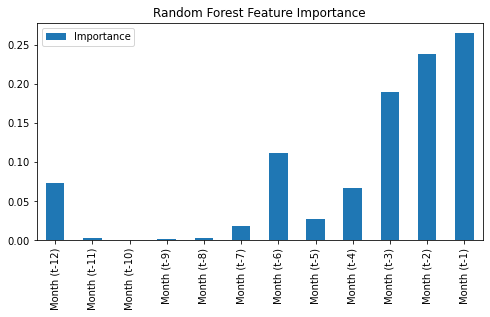

In [9]:
importances_forest = get_feature_importance(forest, X_train)
importances_forest.plot(kind="bar", figsize=(8,4), title="Random Forest Feature Importance");

🌳✨ 7. Extra Trees Model
---
## Extra Trees (Extremely Randomized Trees)

Extra Trees introduce more randomness than Random Forests.  
This often improves accuracy and reduces variance.

We tune, train, evaluate, and extract feature importance.

In [10]:
from exrandomtree.ex_random_tree import (
    optimize_extratrees, train_extratrees, predict_extratrees,
    evaluate_extratrees, get_feature_importance
)

# Tune
results_etr = optimize_extratrees(X_train, Y_train, verbose=0)
best_etr_params = results_etr["params"]

# Train
etr = train_extratrees(X_train, Y_train, **best_etr_params)

# Predict
Y_train_pred_etr = predict_extratrees(etr, X_train)
Y_test_pred_etr = predict_extratrees(etr, X_test)

# Evaluate
MAE_train_etr = evaluate_extratrees(Y_train, Y_train_pred_etr)
MAE_test_etr = evaluate_extratrees(Y_test, Y_test_pred_etr)

MAE_train_etr, MAE_test_etr

(0.11542593815342136, 0.173077728666561)

Feature Importance Visual

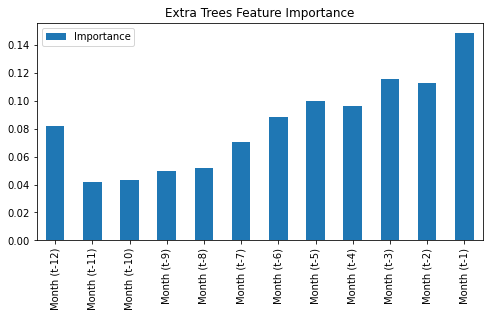

In [11]:
importances_etr = get_feature_importance(etr, X_train)
importances_etr.plot(kind="bar", figsize=(8,4), title="Extra Trees Feature Importance");

📈 8. Model Comparison Table
---
## Model Comparison

We compare all four models using MAE% on both training and test sets.

In [12]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Extra Trees"],
    "Train MAE%": [
        MAE_train_lr*100, MAE_train_tree*100,
        MAE_train_forest*100, MAE_train_etr*100
    ],
    "Test MAE%": [
        MAE_test_lr*100, MAE_test_tree*100,
        MAE_test_forest*100, MAE_test_etr*100
    ]
})

results

,Model,Train MAE%,Test MAE%
0,Linear Regression,17.849047,17.816904
1,Decision Tree,16.799632,18.128781
2,Random Forest,12.048629,17.680001
3,Extra Trees,11.542594,17.307773


# 📉 9. Visualizing Predictions vs Actuals  
## Cleaner, More Interpretable Forecast Visuals

The original “all‑models‑on‑one‑plot” approach created a cluttered line graph that was difficult to interpret. To improve clarity and storytelling, we break the visualization into **two focused views**:

1. **A clean comparison of Actual vs the Best Model (Extra Trees)**  
2. **A residual‑based comparison showing how each model deviates from the truth**

This approach removes visual noise and highlights the true performance differences.

---

## 🎯 9.1 Actual vs Predicted (Best Model Only)

We zoom in on the last `N` observations and compare the actual values to the **Extra Trees** predictions — the top‑performing model. This provides a clear, uncluttered view of how well the model tracks real sales.

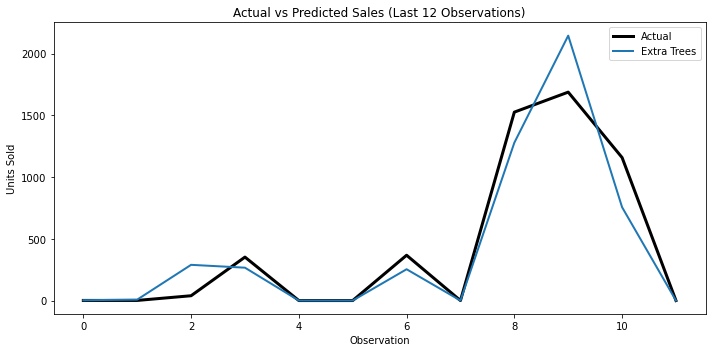

In [14]:
import matplotlib.pyplot as plt

# Choose how many points to show
N = 12

plt.figure(figsize=(10,5))
plt.plot(Y_test[-N:], label="Actual", linewidth=3, color="black")
plt.plot(Y_test_pred_etr[-N:], label="Extra Trees", linewidth=2, color="tab:blue")

plt.legend()
plt.title(f"Actual vs Predicted Sales (Last {N} Observations)")
plt.xlabel("Observation")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

## 🎯 9.2 Prediction Errors (Residuals) for All Models

Instead of plotting all predictions directly — which creates overlapping lines — we visualize **residuals** (Actual − Predicted). This makes it easy to see:

- which models consistently over‑ or under‑predict  
- which model stays closest to zero  
- how stable each model is across the test window 

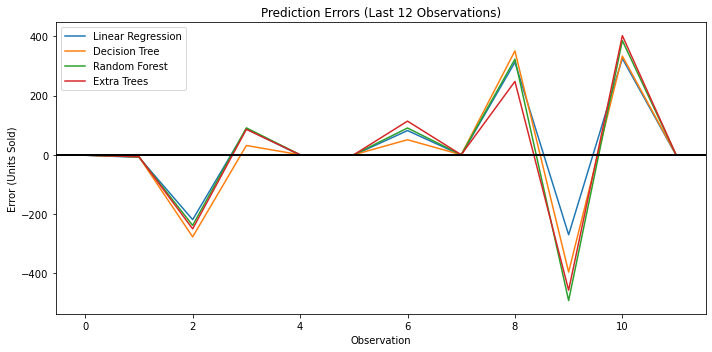

In [15]:
N = 12

plt.figure(figsize=(10,5))
plt.plot((Y_test - Y_test_pred_lr)[-N:], label="Linear Regression")
plt.plot((Y_test - Y_test_pred_tree)[-N:], label="Decision Tree")
plt.plot((Y_test - Y_test_pred_forest)[-N:], label="Random Forest")
plt.plot((Y_test - Y_test_pred_etr)[-N:], label="Extra Trees")

plt.axhline(0, color="black", linewidth=2)
plt.title(f"Prediction Errors (Last {N} Observations)")
plt.xlabel("Observation")
plt.ylabel("Error (Units Sold)")
plt.legend()
plt.tight_layout()
plt.show()

🏁 10. Final Takeaways
---
# Key Takeaways

- **Tree‑based models outperform Linear Regression**, capturing non‑linear patterns.
- **Extra Trees and Random Forest** typically deliver the best accuracy.
- **Feature importance** shows which months of history matter most.
- These models can support:
  - inventory planning  
  - production scheduling  
  - sales forecasting  
  - budgeting and resource allocation  

This analysis provides a strong foundation for forecasting future demand and improving operational decision‑making.